Esta notebook contiene bloques de código útiles para realizar Q-learning en el entorno "Continuous Mountain Car"

In [1]:
import numpy as np
import gymnasium as gym
import random 

In [2]:
# Cambiar render_mode a rgb_array para entrenar/testear
env_id = 'MountainCarContinuous-v0'
env = gym.make(env_id, render_mode='human')

Observation Space

In [3]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Action Space

In [4]:
env.action_space

Box(-1.0, 1.0, (1,), float32)

Discretización de los estados

In [5]:
x_space = np.linspace(-1.2, 0.6, 100)
vel_space = np.linspace(-0.07, 0.07, 100)
x_space

array([-1.2       , -1.18181818, -1.16363636, -1.14545455, -1.12727273,
       -1.10909091, -1.09090909, -1.07272727, -1.05454545, -1.03636364,
       -1.01818182, -1.        , -0.98181818, -0.96363636, -0.94545455,
       -0.92727273, -0.90909091, -0.89090909, -0.87272727, -0.85454545,
       -0.83636364, -0.81818182, -0.8       , -0.78181818, -0.76363636,
       -0.74545455, -0.72727273, -0.70909091, -0.69090909, -0.67272727,
       -0.65454545, -0.63636364, -0.61818182, -0.6       , -0.58181818,
       -0.56363636, -0.54545455, -0.52727273, -0.50909091, -0.49090909,
       -0.47272727, -0.45454545, -0.43636364, -0.41818182, -0.4       ,
       -0.38181818, -0.36363636, -0.34545455, -0.32727273, -0.30909091,
       -0.29090909, -0.27272727, -0.25454545, -0.23636364, -0.21818182,
       -0.2       , -0.18181818, -0.16363636, -0.14545455, -0.12727273,
       -0.10909091, -0.09090909, -0.07272727, -0.05454545, -0.03636364,
       -0.01818182,  0.        ,  0.01818182,  0.03636364,  0.05

Obtener el estado a partir de la observación

In [6]:
def get_state(obs):
    x, vel = obs
    x_bin = np.digitize(x, x_space)
    vel_bin = np.digitize(vel, vel_space)
    return x_bin, vel_bin

In [7]:
state = get_state(np.array([-0.4, 0.02]))
state

(np.int64(45), np.int64(64))

Discretización de las acciones

In [8]:
actions = list(np.linspace(-1, 1, 10))
actions

[np.float64(-1.0),
 np.float64(-0.7777777777777778),
 np.float64(-0.5555555555555556),
 np.float64(-0.33333333333333337),
 np.float64(-0.11111111111111116),
 np.float64(0.11111111111111116),
 np.float64(0.33333333333333326),
 np.float64(0.5555555555555554),
 np.float64(0.7777777777777777),
 np.float64(1.0)]

In [9]:
def get_sample_action():
    return random.choice(actions)

Inicilización de la tabla Q

In [8]:
Q = np.zeros((len(x_space) + 1, len(vel_space) + 1, len(actions)))
Q

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

Obtención de la acción a partir de la tabla Q

In [9]:
def optimal_policy(state, Q):
    action = actions[np.argmax(Q[state])]
    return action

Epsilon-Greedy Policy

In [11]:
def epsilon_greedy_policy(state, Q, epsilon=0.1):
    explore = np.random.binomial(1, epsilon)
    if explore:
        action = get_sample_action()
    else:
        action = optimal_policy(state, Q)
        
    return action

In [13]:
# Testear el agente entrenado (sin exploración)
print("\nTesteando agente entrenado...")
env = gym.make('MountainCarContinuous-v0', render_mode='human')
test_rewards, test_steps = agent.test_agent(env, episodes=3, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")


Testeando agente entrenado...
Test Episode 1 - Reward: -0.28, Steps: 1000
Test Episode 2 - Reward: -0.28, Steps: 1000
Test Episode 3 - Reward: -0.28, Steps: 1000

Promedio de rewards en testing: -0.28
Promedio de steps en testing: 1000.00


Entrenando agente Q-Learning...
Episode 500/5000 - Avg Reward: -85.62, Steps: 2500
Episode 1000/5000 - Avg Reward: -77.78, Steps: 2500
Episode 1500/5000 - Avg Reward: -69.49, Steps: 2500
Episode 2000/5000 - Avg Reward: -61.04, Steps: 2500
Episode 2500/5000 - Avg Reward: -52.60, Steps: 2500
Episode 3000/5000 - Avg Reward: -43.95, Steps: 2500
Episode 3500/5000 - Avg Reward: -35.38, Steps: 2500
Episode 4000/5000 - Avg Reward: -26.84, Steps: 2500
Episode 4500/5000 - Avg Reward: -18.30, Steps: 2500
Episode 5000/5000 - Avg Reward: -9.81, Steps: 2500


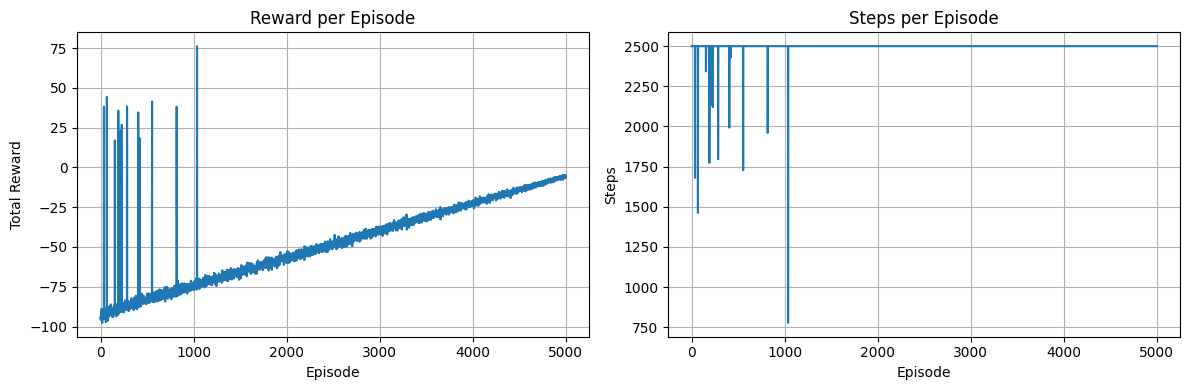

In [ ]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.05,
    max_steps=2500
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()